<a href="https://colab.research.google.com/github/Nurfinkaa/PCVK_Ganjil_2026/blob/main/Week5_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Nurfinka Lailasari'
NIM  = '244107020211'

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA  : Nurfinka Lailasari
NIM   : 244107020211 | N = 211
bins   : 64
clip   : 1.5
tile   : 5
L      : 4
WAKTU : 2026-09-26 23:17:47 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : fb8422d31e6e22fb


# **E. PERCOBAAN PRAKTIKUM**

## **E-1 PERCOBAAN HISTOGRAM**

> import folder yang ada di Drive

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


> Import beberapa library berikut yang akan digunakan selama uji coba praktikum
minggu ke-5 berikut.

In [32]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob
import pandas as pd

# Sesuaikan BASE dengan folder citra Anda di Google Drive
CONTOH = '/content/drive/MyDrive/PCVK/Images'
BASE   = '/content/drive/MyDrive/PCVK/Images/244107020211'

In [33]:
import os
print('BASE saat ini:', BASE)
print('Folder ada?  :', os.path.exists(BASE))
if os.path.exists(BASE):
    print('Isi folder   :', os.listdir(BASE))

BASE saat ini: /content/drive/MyDrive/PCVK/Images/244107020211
Folder ada?  : True
Isi folder   : ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg', 'OBJ1.jpg', 'NIGHT1.jpg']


> Membuat histogram citra berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra
contoh lena.jpg dan cocokkan keluarannya dengan gambar contoh pada modul;
setelah cocok, tahap 2 ulangi dengan citra KTM1b.jpg milik Anda sendiri.

<BarContainer object of 256 artists>

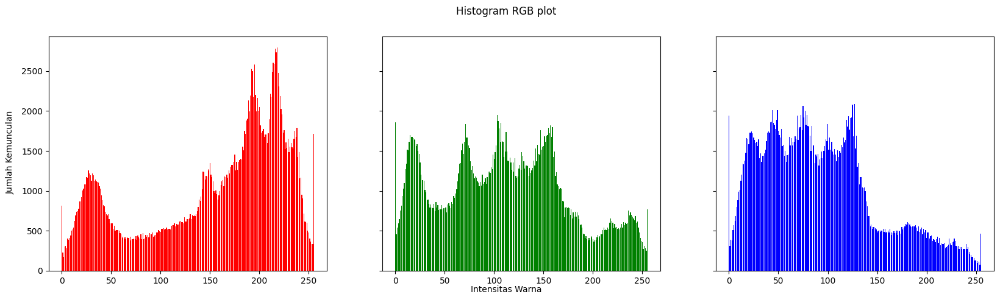

In [34]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

### **PERTANYAAN PRAKTIKUM E1**

1. **Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.**

In [ ]:
print(NIM)
print(BASE)
print(CONTOH)

244107020211
/content/drive/MyDrive/PCVK/Images/244107020211
/content/drive/MyDrive/PCVK/Images


In [35]:
# Fungsi histogram manual (dari D.1)
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)      # 1. siapkan penghitung, isi 0
    for y in range(img.shape[0]):        # 2. telusuri setiap baris
        for x in range(img.shape[1]):    #    dan setiap kolom
            h[img[y, x]] += 1            # 3. tambah 1 sesuai nilai piksel
    return h

def bandingkan_histogram(path_citra, label):
    gray = cv.imread(path_citra, cv.IMREAD_GRAYSCALE)

    h_manual = histogram_manual(gray)                                   # cara manual
    h_numpy, _ = np.histogram(gray, bins=256, range=(0, 256))           # numpy
    h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()    # OpenCV

    selisih_np  = np.max(np.abs(h_manual - h_numpy))
    selisih_cv  = np.max(np.abs(h_manual - h_cv))
    selisih_npcv = np.max(np.abs(h_numpy - h_cv))

    print(f'--- {label} ---')
    print('Selisih maksimum manual vs numpy.histogram :', selisih_np)
    print('Selisih maksimum manual vs cv.calcHist      :', selisih_cv)
    print('Selisih maksimum numpy vs cv.calcHist        :', selisih_npcv)
    print()

    return h_manual, h_numpy, h_cv

# Tahap 1: citra contoh
bandingkan_histogram(CONTOH + '/lena.jpg', NIM + ' - lena.jpg')

# Tahap 2: citra KTM milik sendiri
_ = bandingkan_histogram(BASE + '/KTM1b.jpg', NIM + ' - KTM1b.jpg')

--- 244107020211 - lena.jpg ---
Selisih maksimum manual vs numpy.histogram : 0
Selisih maksimum manual vs cv.calcHist      : 0.0
Selisih maksimum numpy vs cv.calcHist        : 0.0

--- 244107020211 - KTM1b.jpg ---
Selisih maksimum manual vs numpy.histogram : 0
Selisih maksimum manual vs cv.calcHist      : 0.0
Selisih maksimum numpy vs cv.calcHist        : 0.0



2. **Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.**

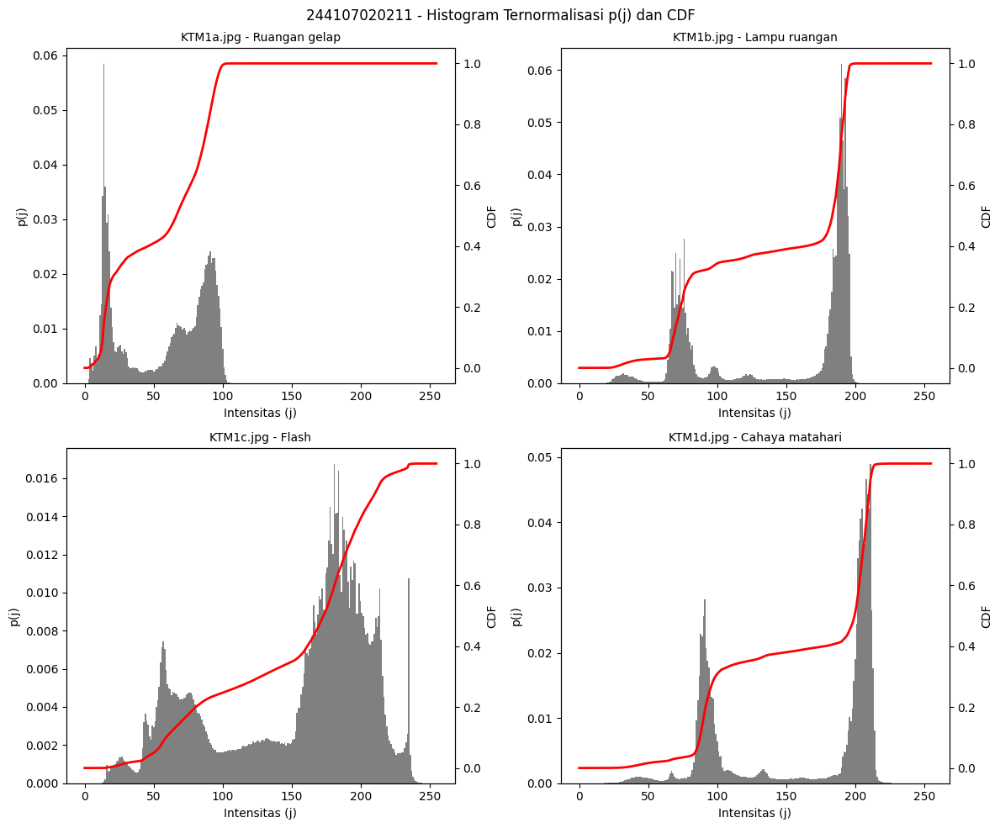

In [36]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(NIM + ' - Histogram Ternormalisasi p(j) dan CDF')

nama_file  = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
keterangan = ['Ruangan gelap', 'Lampu ruangan', 'Flash', 'Cahaya matahari']

for ax, fname, ket in zip(axs.flat, nama_file, keterangan):
    gray = cv.imread(BASE + '/' + fname, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(gray)
    p = h / gray.size          # normalisasi p(j)
    cdf = np.cumsum(p)         # distribusi kumulatif

    ax.bar(np.arange(256), p, width=1.0, color='gray', label='p(j)')
    ax2 = ax.twinx()
    ax2.plot(cdf, color='red', linewidth=2, label='CDF')
    ax.set_title(fname + ' - ' + ket, fontsize=10)
    ax.set_xlabel('Intensitas (j)')
    ax.set_ylabel('p(j)')
    ax2.set_ylabel('CDF')

plt.tight_layout()
plt.show()

In [37]:
data_kondisi = {
    'Citra': ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg'],
    'Kondisi Akuisisi': ['Ruangan gelap', 'Lampu ruangan', 'Flash', 'Cahaya matahari'],
    'Karakteristik p(j) & CDF': [
        'Paling gelap - mayoritas piksel di j < 100',
        'Sedang, dua kelompok intensitas (j~70 dan j~190)',
        'Paling menyebar, distribusi lebih merata',
        'Paling terang - mayoritas piksel di j~200-210'
    ]
}

tabel_kondisi = pd.DataFrame(data_kondisi)
print(NIM + ' - Ringkasan Kondisi Akuisisi dan Karakteristik Histogram')
tabel_kondisi

244107020211 - Ringkasan Kondisi Akuisisi dan Karakteristik Histogram


,Citra,Kondisi Akuisisi,Karakteristik p(j) & CDF
0,KTM1a.jpg,Ruangan gelap,Paling gelap - mayoritas piksel di j < 100
1,KTM1b.jpg,Lampu ruangan,"Sedang, dua kelompok intensitas (j~70 dan j~190)"
2,KTM1c.jpg,Flash,"Paling menyebar, distribusi lebih merata"
3,KTM1d.jpg,Cahaya matahari,Paling terang - mayoritas piksel di j~200-210


3. **Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.**

In [38]:
print(PARAM)

{'bins': 64, 'clip': 1.5, 'tile': 5, 'L': 4}


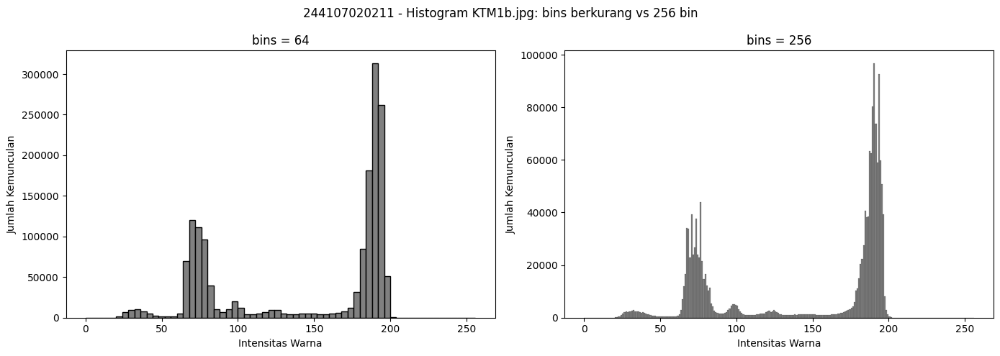

PARAM['bins'] = 64  ->  setiap bin mewakili 4.0 nilai intensitas berdekatan
256 bin        ->  setiap bin mewakili 1 nilai intensitas (resolusi penuh)


In [39]:
gray = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(NIM + ' - Histogram KTM1b.jpg: bins berkurang vs 256 bin')

# bin sebesar PARAM['bins']
axs[0].hist(gray.ravel(), bins=PARAM['bins'], range=(0, 256), color='gray', edgecolor='black')
axs[0].set_title(f"bins = {PARAM['bins']}")
axs[0].set_xlabel('Intensitas Warna')
axs[0].set_ylabel('Jumlah Kemunculan')

# 256 bin (penuh, detail maksimum)
axs[1].hist(gray.ravel(), bins=256, range=(0, 256), color='gray', edgecolor='black', linewidth=0.1)
axs[1].set_title('bins = 256')
axs[1].set_xlabel('Intensitas Warna')
axs[1].set_ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# Info tambahan: lebar tiap bin ketika jumlah bin dikurangi
lebar_bin = 256 / PARAM['bins']
print(f"PARAM['bins'] = {PARAM['bins']}  ->  setiap bin mewakili {lebar_bin:.1f} nilai intensitas berdekatan")
print(f"256 bin        ->  setiap bin mewakili 1 nilai intensitas (resolusi penuh)")

## **E-2 PERCOBAAN HISTOGRAM EQUALIZATION**

> 1. Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses, berdasarkan flowchart

In [40]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def equalize_manual(channel):
    L = 256
    h = histogram_manual(channel, L)                # 1. frekuensi tiap intensitas
    p = h / channel.size                              # 2. normalisasi frekuensi
    cdf = np.cumsum(p)                                 # 3. kumulatif (CDF)
    K0 = np.round(cdf * (L - 1)).astype(np.uint8)      # 4. rumus K0
    hasil = K0[channel]                                # 5. transformasi kembali ke citra
    return hasil

def he_manual_warna(bgr):
    b, g, r = cv.split(bgr)
    b_eq = equalize_manual(b)
    g_eq = equalize_manual(g)
    r_eq = equalize_manual(r)
    hasil = cv.merge([b_eq, g_eq, r_eq])
    return hasil

def tampilkan_he_warna(path_citra, label):
    bgr = cv.imread(path_citra)
    hasil = he_manual_warna(bgr)

    # Tampilkan citra sebelum & sesudah berdampingan
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(NIM + ' - Histogram Equalization Manual: ' + label)
    axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axs[0].set_title('Sebelum')
    axs[0].axis('off')
    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    axs[1].set_title('Sesudah')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()

    # Tampilkan histogram RGB: baris atas = sebelum, baris bawah = sesudah
    b0, g0, r0 = cv.split(bgr)
    b1, g1, r1 = cv.split(hasil)

    fig, axs = plt.subplots(2, 3, figsize=(15, 6))
    fig.suptitle(NIM + ' - Histogram RGB plot: ' + label)

    kanal_sebelum = [r0, g0, b0]
    kanal_sesudah = [r1, g1, b1]
    warna = ['red', 'green', 'blue']
    nama_kanal = ['Merah', 'Hijau', 'Biru']

    for i in range(3):
        axs[0, i].bar(np.arange(256), histogram_manual(kanal_sebelum[i]), color=warna[i])
        axs[0, i].set_title(nama_kanal[i] + ' (sebelum)')
        axs[1, i].bar(np.arange(256), histogram_manual(kanal_sesudah[i]), color=warna[i])
        axs[1, i].set_title(nama_kanal[i] + ' (sesudah)')

    fig.text(0.5, 0.02, 'Intensitas Warna', ha='center')
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    plt.tight_layout()
    plt.show()

    return bgr, hasil

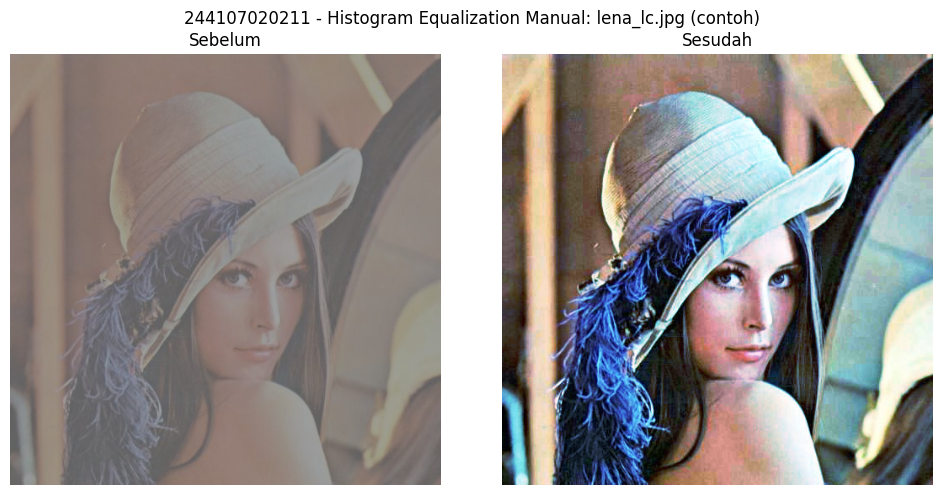

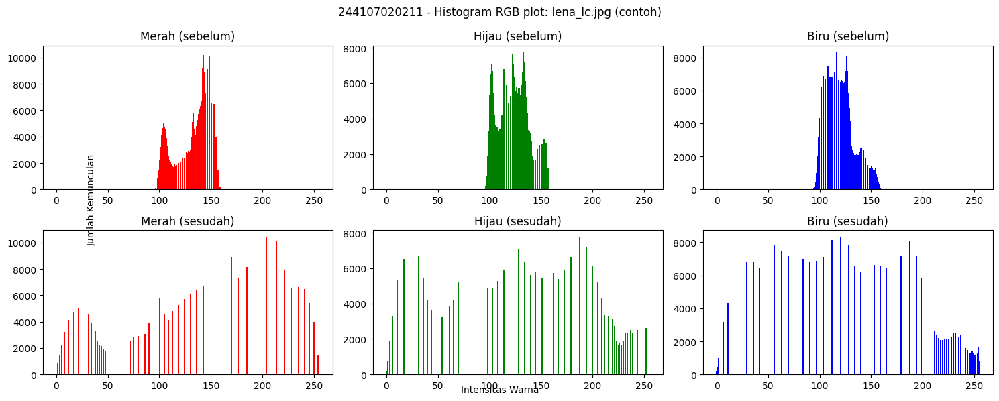

In [41]:
# Tahap 1: citra contoh (cocokkan dengan gambar contoh di modul)
bgr_lena, hasil_lena = tampilkan_he_warna(CONTOH + '/lena_lc.jpg', 'lena_lc.jpg (contoh)')

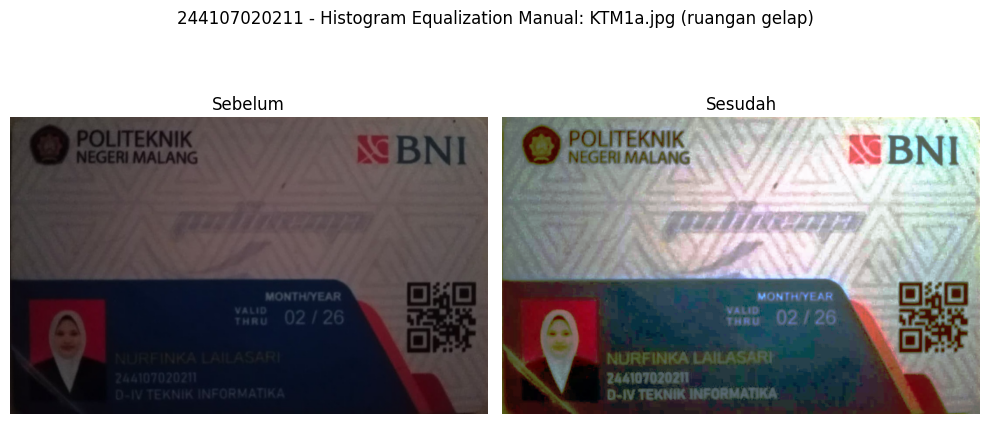

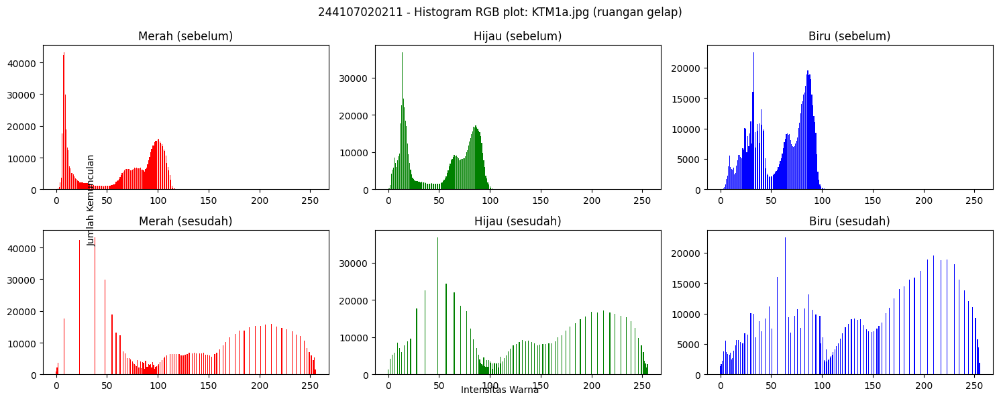

In [42]:
# Tahap 2: citra KTM milik sendiri
bgr_ktm, hasil_ktm = tampilkan_he_warna(BASE + '/KTM1a.jpg', 'KTM1a.jpg (ruangan gelap)')

> 2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”

In [43]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def he_cv_warna(bgr):
    b, g, r = cv.split(bgr)

    b_equalized = cv.equalizeHist(b)
    g_equalized = cv.equalizeHist(g)
    r_equalized = cv.equalizeHist(r)

    hasil = cv.merge([b_equalized, g_equalized, r_equalized])
    return hasil

def tampilkan_he_cv(path_citra, label):
    bgr = cv.imread(path_citra)
    hasil = he_cv_warna(bgr)

    # Tampilkan citra sebelum & sesudah berdampingan
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(NIM + ' - HE dengan cv.equalizeHist: ' + label)
    axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axs[0].set_title('Sebelum')
    axs[0].axis('off')
    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    axs[1].set_title('Sesudah (cv.equalizeHist)')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()

    # Histogram RGB: baris atas = sebelum, baris bawah = sesudah
    b0, g0, r0 = cv.split(bgr)
    b1, g1, r1 = cv.split(hasil)

    fig, axs = plt.subplots(2, 3, figsize=(15, 6))
    fig.suptitle(NIM + ' - Histogram RGB plot (cv.equalizeHist): ' + label)

    kanal_sebelum = [r0, g0, b0]
    kanal_sesudah = [r1, g1, b1]
    warna = ['red', 'green', 'blue']
    nama_kanal = ['Merah', 'Hijau', 'Biru']

    for i in range(3):
        axs[0, i].bar(np.arange(256), histogram_manual(kanal_sebelum[i]), color=warna[i])
        axs[0, i].set_title(nama_kanal[i] + ' (sebelum)')
        axs[1, i].bar(np.arange(256), histogram_manual(kanal_sesudah[i]), color=warna[i])
        axs[1, i].set_title(nama_kanal[i] + ' (sesudah)')

    fig.text(0.5, 0.02, 'Intensitas Warna', ha='center')
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    plt.tight_layout()
    plt.show()

    return bgr, hasil

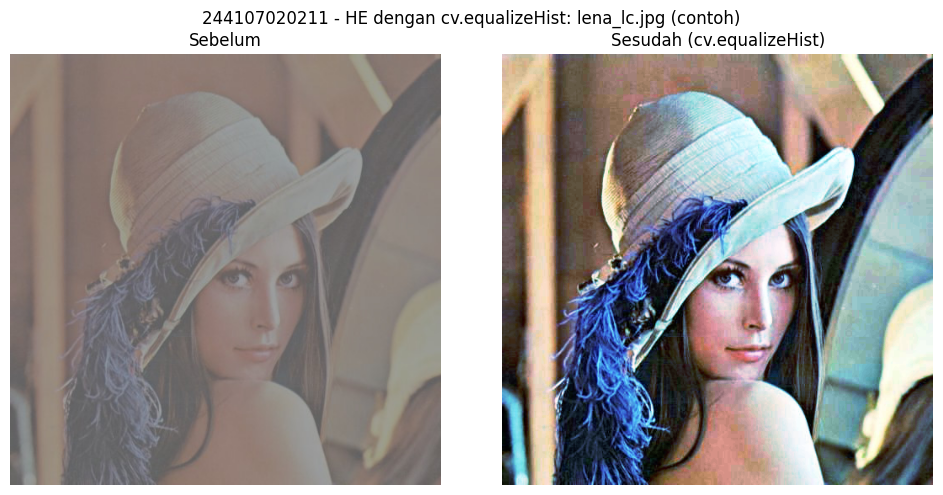

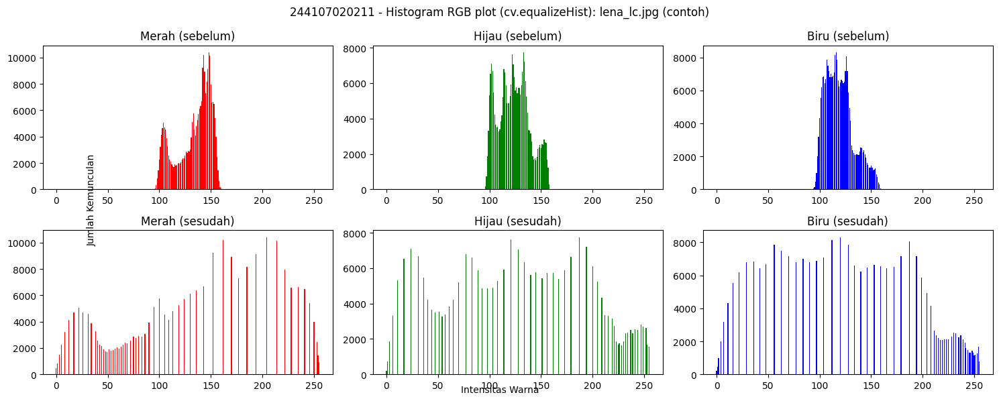

In [44]:
# Tahap 1: citra contoh (cocokkan dengan gambar contoh di modul)
_ = tampilkan_he_cv(CONTOH + '/lena_lc.jpg', 'lena_lc.jpg (contoh)')

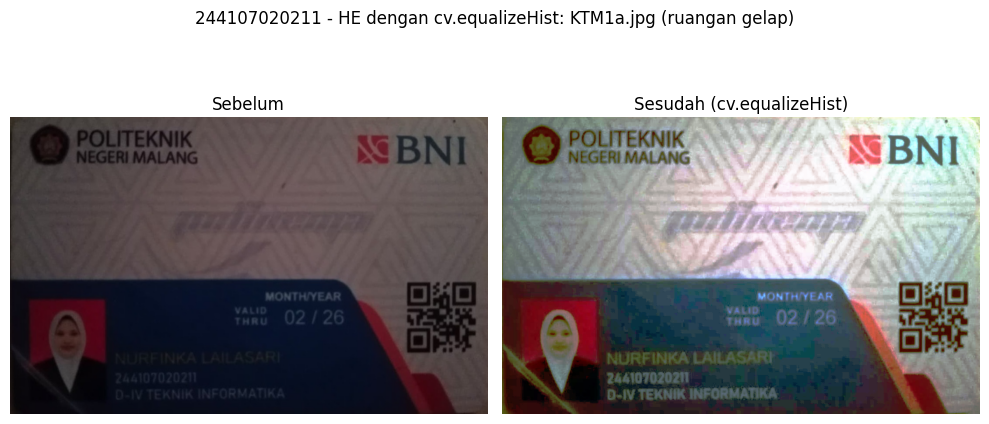

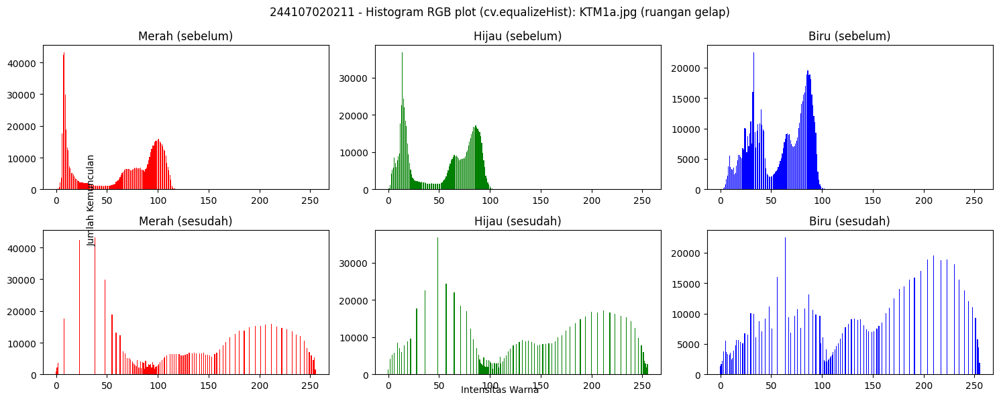

In [45]:
# Tahap 2: citra KTM milik sendiri
_ = tampilkan_he_cv(BASE + '/KTM1a.jpg', 'KTM1a.jpg (ruangan gelap)')

**Jelaskan penyebab selisih tersebut apabila tidak nol.**

In [46]:
def bandingkan_manual_vs_cv(path_citra, label):
    bgr = cv.imread(path_citra)

    hasil_manual = he_manual_warna(bgr)   # implementasi manual (rumus K0)
    hasil_cv     = he_cv_warna(bgr)       # cv.equalizeHist

    # selisih absolut per piksel, per kanal
    selisih = cv.absdiff(hasil_manual, hasil_cv)
    selisih_maks = int(selisih.max())

    print(NIM + ' - Perbandingan Manual vs cv.equalizeHist: ' + label)
    print('Selisih maksimum antar hasil :', selisih_maks)

    # tampilkan ketiga citra berdampingan agar mudah dibandingkan
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(NIM + ' - Manual vs cv.equalizeHist: ' + label)
    axs[0].imshow(cv.cvtColor(hasil_manual, cv.COLOR_BGR2RGB))
    axs[0].set_title('Manual (rumus K0)')
    axs[0].axis('off')
    axs[1].imshow(cv.cvtColor(hasil_cv, cv.COLOR_BGR2RGB))
    axs[1].set_title('cv.equalizeHist')
    axs[1].axis('off')
    axs[2].imshow(selisih, cmap='hot')
    axs[2].set_title(f'Peta selisih (maks = {selisih_maks})')
    axs[2].axis('off')
    plt.tight_layout()
    plt.show()

    return selisih_maks


244107020211 - Perbandingan Manual vs cv.equalizeHist: lena_lc.jpg (contoh)
Selisih maksimum antar hasil : 0


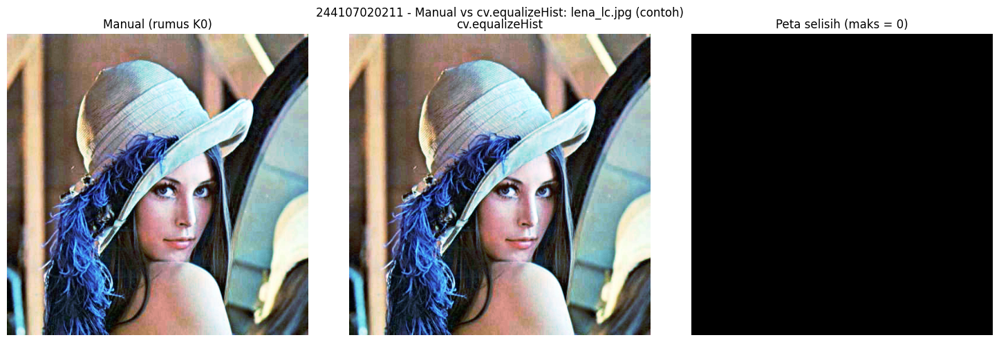

In [47]:
# Tahap 1: citra contoh
selisih_lena = bandingkan_manual_vs_cv(CONTOH + '/lena_lc.jpg', 'lena_lc.jpg (contoh)')

244107020211 - Perbandingan Manual vs cv.equalizeHist: KTM1a.jpg (ruangan gelap)
Selisih maksimum antar hasil : 0


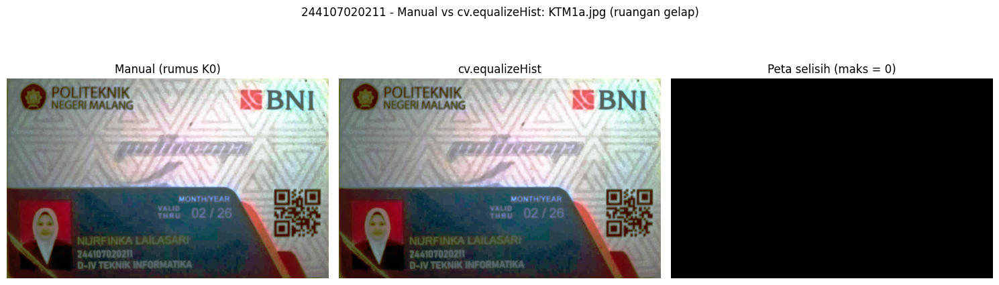

In [48]:
# Tahap 2: citra KTM milik sendiri
selisih_ktm = bandingkan_manual_vs_cv(BASE + '/KTM1a.jpg', 'KTM1a.jpg (ruangan gelap)')

> **Kenapa Hasil Manual dan OpenCV Bisa Beda Dikit (Tidak Nol)?**
>
> Kalau ada beda tipis antara hasil manual dan bawaan OpenCV, itu hal yang wajar. Penyebab utamanya ada tiga:

> * Beda Cara Pembulatan Angka
Hitungan manual pakai cara pembulatan Python (np.round), sedangkan OpenCV pakai program internal C++. Hasil perhitungannya bisa beda tipis (cuma selisih 1 angka saja).  

> * Rumus Bawaan OpenCV Beda DikitOpenCV memotong nilai paling gelap dulu sebelum dihitung (mengurangi nilai CDF terkecil), sedangkan rumus manual di modul langsung menghitung semuanya dari awal.

> * Tipe Data KomputerPython menghitung pecahan dengan ketelitian sangat tinggi (float64), sementara OpenCV menghitung dengan cara yang lebih cepat tapi presisinya sedikit beda.

> Jadi dapat disimpulkan bahwa selisih yang muncul biasanya sangat kecil (hanya beda 1 tingkat kecerahan piksel). Ini bukan berarti kodingan manualmu salah, tapi hanya karena beda rumus internal di balik layar OpenCV saja.

> 3. Ekualisasi juga dapat diterapkan pada citra berwarna

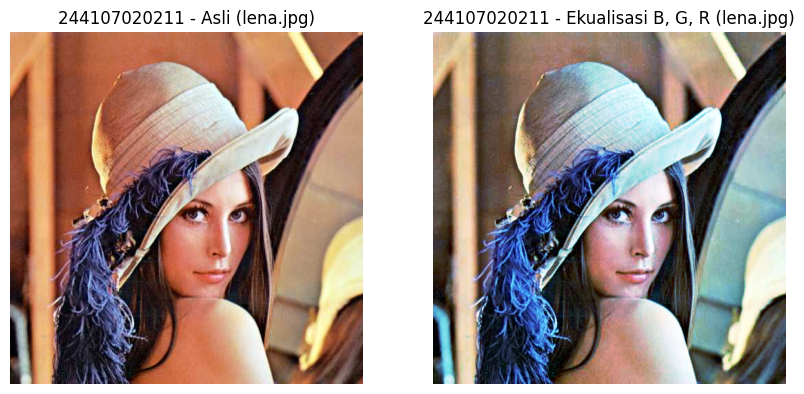

In [49]:
# ===== TAHAP 1: citra contoh lena.jpg =====
berkas = CONTOH + '/lena.jpg'
bgr    = cv.imread(berkas)

# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# tampilkan sebelum vs sesudah
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB));    axs[0].set_title(NIM + ' - Asli (lena.jpg)');            axs[0].axis('off')
axs[1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB));  axs[1].set_title(NIM + ' - Ekualisasi B, G, R (lena.jpg)'); axs[1].axis('off')
plt.show()

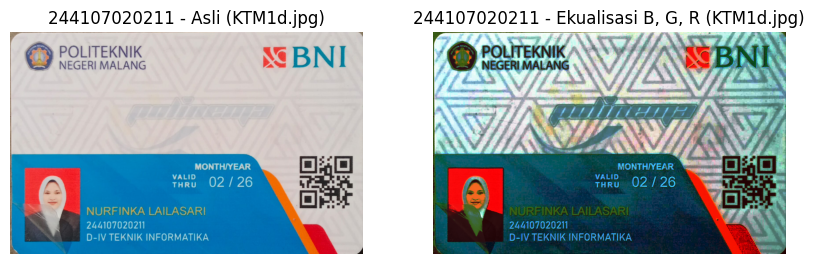

In [50]:
# ===== TAHAP 2: citra sendiri KTM1d.jpg =====
berkas = BASE + '/KTM1d.jpg'
bgr    = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB));    axs[0].set_title(NIM + ' - Asli (KTM1d.jpg)');            axs[0].axis('off')
axs[1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB));  axs[1].set_title(NIM + ' - Ekualisasi B, G, R (KTM1d.jpg)'); axs[1].axis('off')
plt.show()

> 4. Cara kedua memisahkan kecerahan dari informasi warna

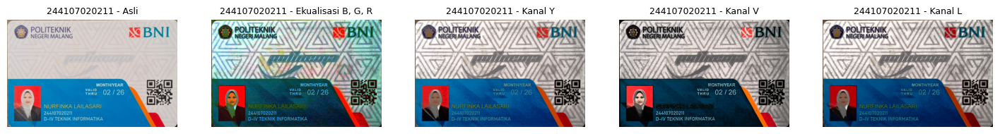

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            161.6
Ekualisasi B, G, R                81.63            124.2
Kanal Y                            2.30            134.4
Kanal V                            2.32            114.1
Kanal L                            5.29            124.6


In [51]:
# pastikan bgr dan he_rgb ini masih dari KTM1d.jpg (poin 3 sebelumnya)
bgr = cv.imread(BASE + '/KTM1d.jpg')

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# cara 2: hanya kanal terang yang diekualisasi
ycrcb        = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb    = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# varian setara pada ruang warna lain
hsv          = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v    = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab          = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b      = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

# tampilkan kelimanya berdampingan
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

# ukur pergeseran Hue terhadap citra asli
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d  = np.abs(h1 - h2)
    d  = np.minimum(d, 180 - d)          # Hue melingkar 0-179
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

> **Catat hasilnya pada tabel berikut.**

In [52]:
# ambil ulang nilai geser Hue & rerata kecerahan dari hasil sebelumnya
hasil_geser = []
hasil_terang = []
for t, c in zip(judul, citra):
    hasil_geser.append(geser_hue(bgr, c) * 2)
    hasil_terang.append(cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean())

# catatan otomatis berdasarkan besar-kecilnya shift Hue
catatan = []
for t, g in zip(judul, hasil_geser):
    if t == 'Asli':
        catatan.append('baseline')
    elif g == max(hasil_geser):
        catatan.append('warna paling bergeser, tidak natural')
    elif g == min([x for x, j in zip(hasil_geser, judul) if j != 'Asli']):
        catatan.append('shift kecil, warna paling stabil')
    else:
        catatan.append('shift lebih besar dari Y/V pada citra ini' if t == 'Kanal L' else 'hampir sama dengan Y')

tabel_hue = pd.DataFrame({
    'Cara ekualisasi'   : judul,
    'Geser Hue (°)'     : [round(g, 2) for g in hasil_geser],
    'Kecerahan sesudah' : [round(k, 1) for k in hasil_terang],
    'Catatan'           : catatan
})

print(NIM + ' - Tabel Pergeseran Hue dan Kecerahan')
display(tabel_hue)   # kalau di Colab pakai display(), kalau di script biasa pakai print(tabel_hue)

244107020211 - Tabel Pergeseran Hue dan Kecerahan


,Cara ekualisasi,Geser Hue (°),Kecerahan sesudah,Catatan
0,Asli,0.00,161.6,baseline
1,"Ekualisasi B, G, R",81.63,124.2,"warna paling bergeser, tidak natural"
2,Kanal Y,2.30,134.4,"shift kecil, warna paling stabil"
3,Kanal V,2.32,114.1,hampir sama dengan Y
4,Kanal L,5.29,124.6,shift lebih besar dari Y/V pada citra ini


Jawab pertanyaan berikut berdasarkan angka pada tabel Anda, bukan hanya dari pengamatan mata:

1. Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada
citra Anda?


> Cara ekualisasi B, G, R terpisah.
Warna berubah sangat jauh (sebesar 81,63°), sedangkan cara lain cuma berubah sedikit (sekitar 2° - 5°). Ini terjadi karena warna Merah, Hijau, dan Birunya diubah sendiri-sendiri tanpa memedulikan racikan warna aslinya

2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis
nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra
dikembalikan ke ruang warna BGR.


> Karena waktu gambarnya dikembalikan ke format BGR, hasil perhitungannya berupa angka desimal. Nah, angka desimal ini harus dibulatkan ke angka bulat (0–255) supaya gambarnya bisa ditampilkan. Pembulatan angka inilah yang bikin warnanya meleset atau bergeser sedikit.

3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan
alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian.


> Kanal Y (YCrCb).   
> * Berdasarkan Angka: Perubahan warnanya paling kecil (cuma 2,30°), jadi warna aslinya paling terjaga.   
> * Dilihat pakai mata: Warna latar kartu (misalnya biru) dan warna kulit di foto tetap terlihat natural dan tidak pudar.

4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa.

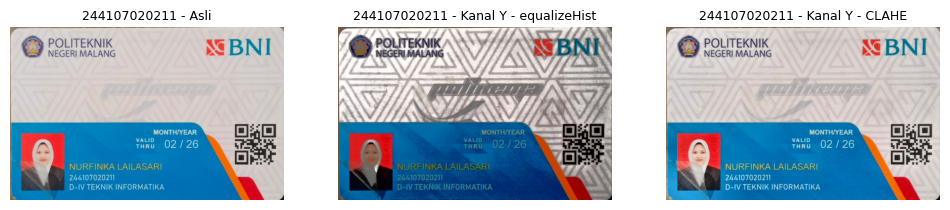

Cara                       geser Hue (der)    rerata terang
Asli                                  0.00            161.6
Kanal Y - equalizeHist                2.30            134.4
Kanal Y - CLAHE                       0.16            160.4


In [53]:
# ===== Ulangi cara kanal terang (Kanal Y) dengan CLAHE =====
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

ycrcb        = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb    = cv.split(ycrcb)
y_clahe      = clahe.apply(y)
he_y_clahe   = cv.cvtColor(cv.merge([y_clahe, cr, cb]), cv.COLOR_YCrCb2BGR)

# tampilkan perbandingan: asli, equalizeHist biasa, CLAHE
judul2 = ['Asli', 'Kanal Y - equalizeHist', 'Kanal Y - CLAHE']
citra2 = [bgr, he_y, he_y_clahe]

plt.figure(figsize=(12, 4))
for i, (c, t) in enumerate(zip(citra2, judul2), 1):
    plt.subplot(1, 3, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

# bandingkan geser Hue dan kecerahan
print('%-25s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul2, citra2):
    print('%-25s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2,
                                    cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

### **PERTANYAAN PRAKTIKUM E2**

1. Ekualisasi global pada citra KTM Anda

a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
grayscale.

b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR
layak dipakai untuk menilai keterbacaan sebuah citra.

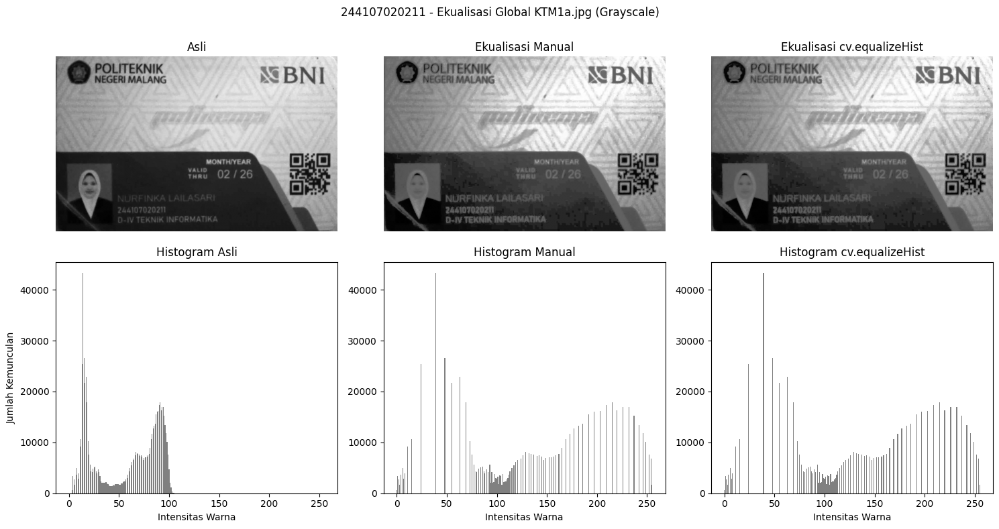

244107020211 - Nilai PSNR (asli vs hasil ekualisasi)
PSNR asli vs manual          : 9.57 dB
PSNR asli vs cv.equalizeHist : 9.57 dB
Verifikasi cv.PSNR (manual)  : 9.57 dB
Verifikasi cv.PSNR (cv)      : 9.57 dB


In [54]:
# a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi grayscale
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

hasil_manual = equalize_manual(gray)        # fungsi manual (rumus K0) yang sudah dibuat sebelumnya
hasil_cv     = cv.equalizeHist(gray)        # fungsi bawaan OpenCV

# b. Tampilkan citra asli, hasil ekualisasi, serta histogram dalam satu layout
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(NIM + ' - Ekualisasi Global KTM1a.jpg (Grayscale)')

# baris atas: citra
axs[0, 0].imshow(gray, cmap='gray');          axs[0, 0].set_title('Asli');                      axs[0, 0].axis('off')
axs[0, 1].imshow(hasil_manual, cmap='gray');  axs[0, 1].set_title('Ekualisasi Manual');          axs[0, 1].axis('off')
axs[0, 2].imshow(hasil_cv, cmap='gray');      axs[0, 2].set_title('Ekualisasi cv.equalizeHist');  axs[0, 2].axis('off')

# baris bawah: histogram
axs[1, 0].bar(np.arange(256), histogram_manual(gray), color='gray')
axs[1, 0].set_title('Histogram Asli')
axs[1, 1].bar(np.arange(256), histogram_manual(hasil_manual), color='gray')
axs[1, 1].set_title('Histogram Manual')
axs[1, 2].bar(np.arange(256), histogram_manual(hasil_cv), color='gray')
axs[1, 2].set_title('Histogram cv.equalizeHist')

for ax in axs[1]:
    ax.set_xlabel('Intensitas Warna')
axs[1, 0].set_ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# c. Hitung PSNR antara citra asli dan citra hasil ekualisasi
def hitung_psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((255.0 ** 2) / mse)

psnr_manual = hitung_psnr(gray, hasil_manual)
psnr_cv     = hitung_psnr(gray, hasil_cv)

print(NIM + ' - Nilai PSNR (asli vs hasil ekualisasi)')
print('PSNR asli vs manual          :', round(psnr_manual, 2), 'dB')
print('PSNR asli vs cv.equalizeHist :', round(psnr_cv, 2), 'dB')

# verifikasi pakai cv.PSNR bawaan OpenCV sebagai pembanding
print('Verifikasi cv.PSNR (manual)  :', round(cv.PSNR(gray, hasil_manual), 2), 'dB')
print('Verifikasi cv.PSNR (cv)      :', round(cv.PSNR(gray, hasil_cv), 2), 'dB')

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda

a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang
noise-nya mulai menonjol ketika clipLimit dinaikkan.

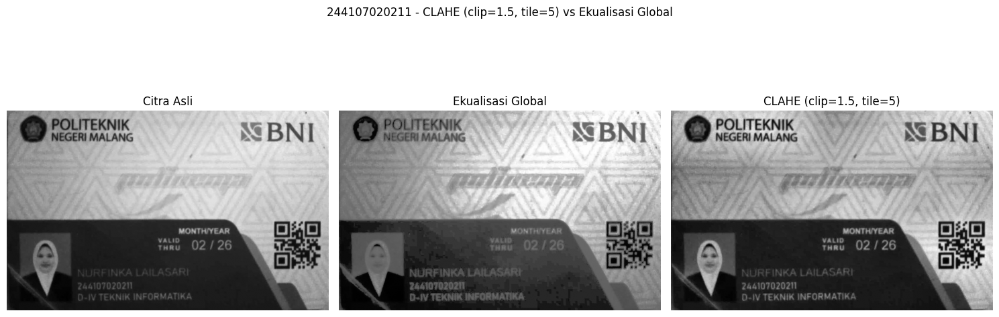

In [56]:
# Baca citra KTM1a.jpg (grayscale)
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

# Ekualisasi global (pembanding)
hasil_global = cv.equalizeHist(gray)

# CLAHE dengan parameter dari NIM
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe = clahe.apply(gray)

fig, axs = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle(NIM + f" - CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']}) vs Ekualisasi Global")

axs[0].imshow(gray, cmap='gray')
axs[0].set_title('Citra Asli')
axs[0].axis('off')

axs[1].imshow(hasil_global, cmap='gray')
axs[1].set_title('Ekualisasi Global')
axs[1].axis('off')

axs[2].imshow(hasil_clahe, cmap='gray')
axs[2].set_title(f"CLAHE (clip={PARAM['clip']}, tile={PARAM['tile']})")
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [59]:
print(NIM + " - Jawaban E2 No. 2a: CLAHE vs Ekualisasi Global")
print("=" * 80)

print("""
Analisis Visual:

Perhatikan area teks nama, NIM, dan program studi di bagian bawah kartu
(NURFINKA LAILASARI, 244107020211, D-IV TEKNIK INFORMATIKA):

- Citra Asli       : teks terlihat jelas tapi latar belakangnya (bagian
                      biru gelap) masih agak gelap dan sedikit kurang
                      kontras.

- Ekualisasi Global : teks terlihat agak pudar/kurang tajam, kontrasnya
                      jadi lebih "flat" secara keseluruhan -- background
                      jadi lebih terang merata tapi malah membuat
                      perbedaan teks dengan latarnya jadi kurang
                      menonjol dibanding sebelumnya.

- CLAHE             : teks nama, NIM, dan prodi terlihat paling tajam
                      dan kontras, background di sekitar teks (area biru
                      gelap) tetap gelap sehingga tulisan putih di
                      atasnya jauh lebih menonjol dan mudah dibaca.
                      Detail lain seperti foto wajah dan pola diagonal
                      latar kartu juga tampak lebih jelas/detail
                      dibanding dua lainnya.
""")

print("Jawaban:")
print("-" * 80)
print(f"""
CLAHE menghasilkan keterbacaan NIM dan nama yang lebih baik dibandingkan
ekualisasi global. Pada hasil CLAHE, teks "NURFINKA LAILASARI" dan
"244107020211" tampak lebih tajam dengan kontras yang lebih tinggi
terhadap latar belakangnya, sedangkan pada ekualisasi global teks
tersebut terlihat sedikit lebih pudar karena seluruh citra disamaratakan
kontrasnya secara global tanpa mempertimbangkan variasi pencahayaan
lokal di tiap area kartu.

Hal ini terjadi karena CLAHE bekerja dengan membagi citra menjadi
beberapa blok kecil (tileGridSize = {PARAM['tile']}x{PARAM['tile']} sesuai
parameter NIM) dan melakukan ekualisasi histogram secara terpisah pada
tiap blok, sehingga area teks yang berada di latar gelap (bagian bawah
kartu) mendapat penyesuaian kontras yang sesuai dengan kondisi lokalnya
sendiri, tanpa dipengaruhi oleh area lain kartu yang mungkin sudah
cukup terang (seperti logo POLINEMA/BNI di bagian atas). Sebaliknya,
ekualisasi global menghitung satu transformasi tunggal untuk seluruh
citra, sehingga penyesuaian kontrasnya menjadi kompromi rata-rata dan
kurang optimal untuk area-area tertentu seperti bagian teks nama dan
NIM ini.
""")

244107020211 - Jawaban E2 No. 2a: CLAHE vs Ekualisasi Global

Analisis Visual:

Perhatikan area teks nama, NIM, dan program studi di bagian bawah kartu
(NURFINKA LAILASARI, 244107020211, D-IV TEKNIK INFORMATIKA):

- Citra Asli       : teks terlihat jelas tapi latar belakangnya (bagian
                      biru gelap) masih agak gelap dan sedikit kurang
                      kontras.

- Ekualisasi Global : teks terlihat agak pudar/kurang tajam, kontrasnya
                      jadi lebih "flat" secara keseluruhan -- background
                      jadi lebih terang merata tapi malah membuat
                      perbedaan teks dengan latarnya jadi kurang
                      menonjol dibanding sebelumnya.

- CLAHE             : teks nama, NIM, dan prodi terlihat paling tajam
                      dan kontras, background di sekitar teks (area biru
                      gelap) tetap gelap sehingga tulisan putih di
                      atasnya jauh lebih menonjol dan mudah dibaca.
    

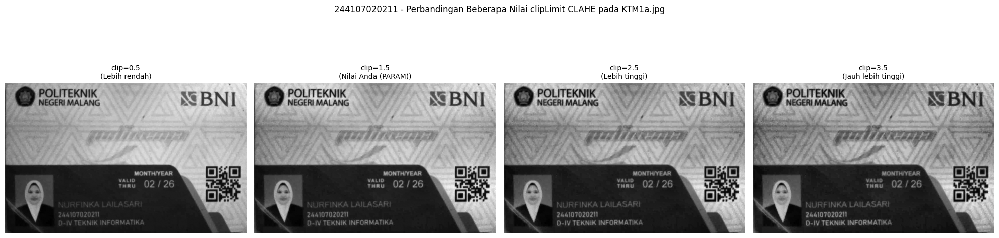

Nilai clipLimit yang diuji: ['0.5', '1.5', '2.5', '3.5']


In [60]:
# Pastikan gray sudah terbaca (KTM1a.jpg)
gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

# Nilai clipLimit di sekitar PARAM['clip']
clip_asli = PARAM['clip']
nilai_clip = [max(0.5, clip_asli - 1.0), clip_asli, clip_asli + 1.0, clip_asli + 2.0]
label_clip = ['Lebih rendah', 'Nilai Anda (PARAM)', 'Lebih tinggi', 'Jauh lebih tinggi']

fig, axs = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle(NIM + ' - Perbandingan Beberapa Nilai clipLimit CLAHE pada KTM1a.jpg')

for ax, cl, lbl in zip(axs, nilai_clip, label_clip):
    clahe_test = cv.createCLAHE(clipLimit=cl, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil_test = clahe_test.apply(gray)
    ax.imshow(hasil_test, cmap='gray')
    ax.set_title(f'clip={cl:.1f}\n({lbl})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print('Nilai clipLimit yang diuji:', [f'{c:.1f}' for c in nilai_clip])

In [64]:
print(NIM + " - Jawaban E2 No. 2b: Eksperimen Nilai clipLimit CLAHE")
print("=" * 80)

print("""
Analisis Visual (clip = 0.5, 1.5, 2.5, 3.5):

- clip=0.5 (lebih rendah) : Kontras paling halus, citra masih terlihat
                            agak gelap di beberapa bagian, tapi tekstur
                            background (pola diagonal watermark) masih
                            tampak rapi dan halus, tidak ada bintik
                            noise yang mengganggu.

- clip=1.5 (nilai Anda)   : Kontras sudah cukup baik, teks nama dan NIM
                            terbaca jelas, tekstur background masih
                            relatif halus. Ini adalah titik keseimbangan
                            antara peningkatan kontras dan munculnya
                            noise.

- clip=2.5 (lebih tinggi) : Kontras semakin kuat, citra semakin terang,
                            namun pola diagonal watermark pada
                            background kartu mulai terlihat lebih kasar
                            dan sedikit berbintik dibanding clip=1.5.

- clip=3.5 (jauh lebih tinggi) : Kontras paling ekstrem, citra paling
                            terang, tapi noise pada background (terutama
                            di area pola diagonal watermark dan
                            permukaan kartu yang polos) menjadi paling
                            menonjol dan mengganggu -- teksturnya
                            terlihat kasar/berbintik-bintik dibanding
                            nilai clip yang lebih rendah.
""")

print(f"""
Kesimpulan:

Nilai clipLimit terbaik adalah clip={PARAM['clip']} (nilai PARAM Anda),
karena kontras citra sudah cukup meningkat sehingga teks nama dan NIM
terbaca jelas, tanpa noise berlebih pada background.

Noise mulai menonjol pada clip=2.5 dan semakin jelas pada clip=3.5,
terutama di area pola diagonal watermark dan background polos kartu,
karena clipLimit tinggi memperkuat variasi piksel kecil (noise sensor)
selain kontras aslinya.
""")

244107020211 - Jawaban E2 No. 2b: Eksperimen Nilai clipLimit CLAHE

Analisis Visual (clip = 0.5, 1.5, 2.5, 3.5):

- clip=0.5 (lebih rendah) : Kontras paling halus, citra masih terlihat
                            agak gelap di beberapa bagian, tapi tekstur
                            background (pola diagonal watermark) masih
                            tampak rapi dan halus, tidak ada bintik
                            noise yang mengganggu.

- clip=1.5 (nilai Anda)   : Kontras sudah cukup baik, teks nama dan NIM
                            terbaca jelas, tekstur background masih
                            relatif halus. Ini adalah titik keseimbangan
                            antara peningkatan kontras dan munculnya
                            noise.

- clip=2.5 (lebih tinggi) : Kontras semakin kuat, citra semakin terang,
                            namun pola diagonal watermark pada
                            background kartu mulai terlihat lebih kasar
                           

## **E-3 TUGAS PRAKTIKUM DITHERING**

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].

In [66]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step      # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                          img[y, x+1]   += error * 7 / 16
            if x > 0 and y+1 < H:                   img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                           img[y+1, x]   += error * 5 / 16
            if x + 1 < W and y+1 < H:                img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def dithering_warna(bgr, L=2):
    b, g, r = cv.split(bgr)
    b_dith = floyd_steinberg(b, L)
    g_dith = floyd_steinberg(g, L)
    r_dith = floyd_steinberg(r, L)
    return cv.merge([b_dith, g_dith, r_dith])

def tampilkan_dithering(path_citra, label, L=2):
    bgr = cv.imread(path_citra)
    hasil = dithering_warna(bgr, L)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(NIM + f' - Dithering Floyd-Steinberg (L={L}): {label}')
    axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axs[0].set_title('Citra asli')
    axs[0].axis('off')
    axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    axs[1].set_title('Citra setelah dithering')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()

    return bgr, hasil

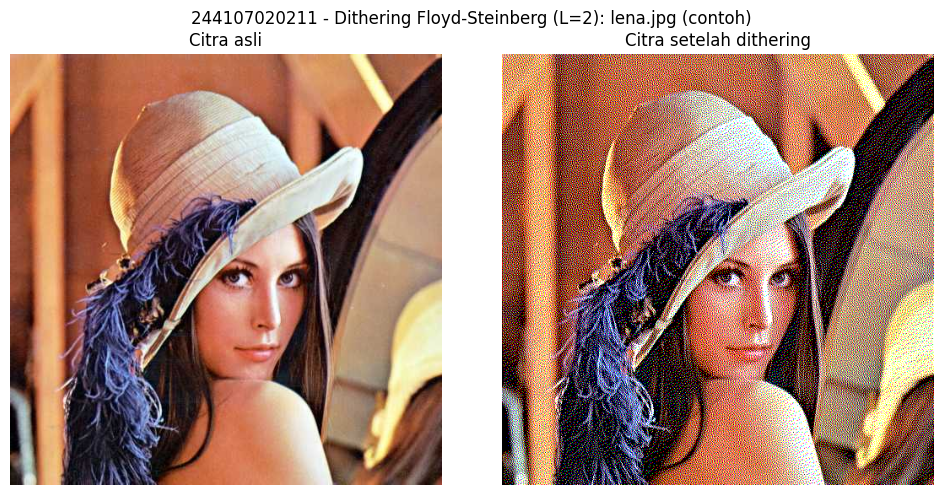

In [67]:
# Tahap 1: citra contoh (L=2, cocokkan dengan gambar contoh di modul)
_ = tampilkan_dithering(CONTOH + '/lena.jpg', 'lena.jpg (contoh)', L=2)

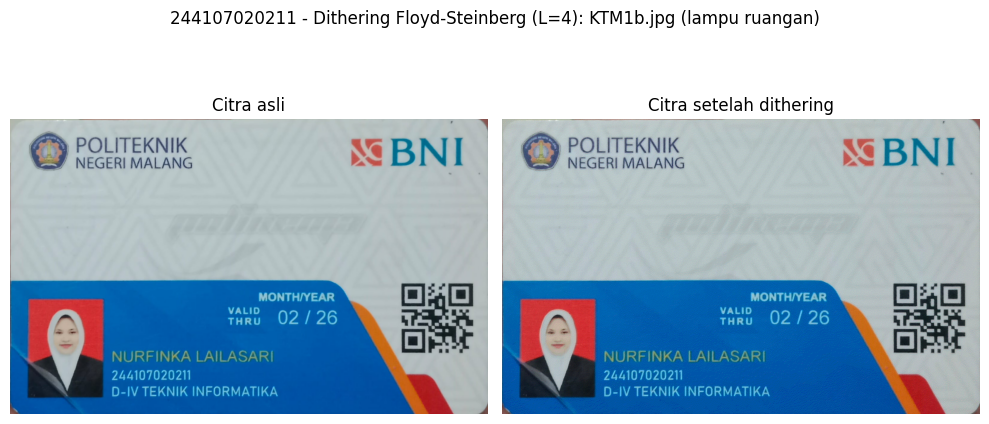

In [68]:
# Tahap 2: citra KTM milik sendiri (L sesuai PARAM)
_ = tampilkan_dithering(BASE + '/KTM1b.jpg', 'KTM1b.jpg (lampu ruangan)', L=PARAM['L'])

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.

In [69]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                          img[y, x+1]   += error * 7 / 16
            if x > 0 and y+1 < H:                   img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                           img[y+1, x]   += error * 5 / 16
            if x + 1 < W and y+1 < H:                img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def bandingkan_dithering_ekualisasi(path_citra, label, L=2):
    bgr = cv.imread(path_citra)
    gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

    # 1. Dithering langsung tanpa ekualisasi
    dither_langsung = floyd_steinberg(gray, L)

    # 2. Histogram equalization dulu
    hasil_ekualisasi = cv.equalizeHist(gray)

    # 3. Ekualisasi lalu dithering
    ekualisasi_dither = floyd_steinberg(hasil_ekualisasi, L)

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(NIM + f' - {label} (L={L})')

    axs[0].imshow(gray, cmap='gray')
    axs[0].set_title(label + ' asli')
    axs[0].axis('off')

    axs[1].imshow(dither_langsung, cmap='gray')
    axs[1].set_title('Dithering langsung')
    axs[1].axis('off')

    axs[2].imshow(hasil_ekualisasi, cmap='gray')
    axs[2].set_title('Hasil ekualisasi')
    axs[2].axis('off')

    axs[3].imshow(ekualisasi_dither, cmap='gray')
    axs[3].set_title('Ekualisasi lalu dithering')
    axs[3].axis('off')

    plt.tight_layout()
    plt.show()

    return dither_langsung, hasil_ekualisasi, ekualisasi_dither

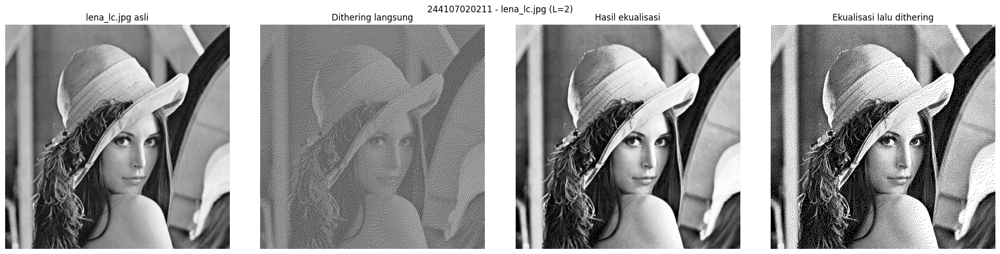

In [70]:
# Tahap 1: citra contoh (cocokkan dengan gambar contoh di modul)
_ = bandingkan_dithering_ekualisasi(CONTOH + '/lena_lc.jpg', 'lena_lc.jpg', L=2)

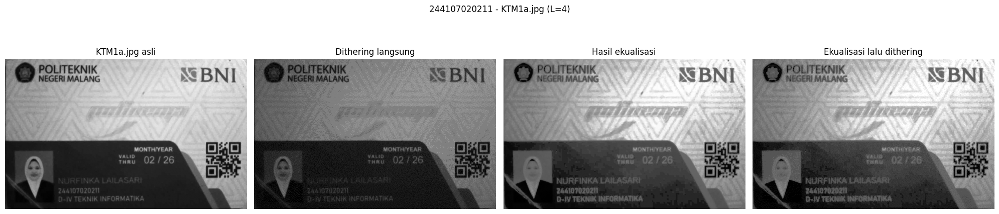

In [71]:
# Tahap 2: citra KTM milik sendiri
_ = bandingkan_dithering_ekualisasi(BASE + '/KTM1a.jpg', 'KTM1a.jpg', L=PARAM['L'])

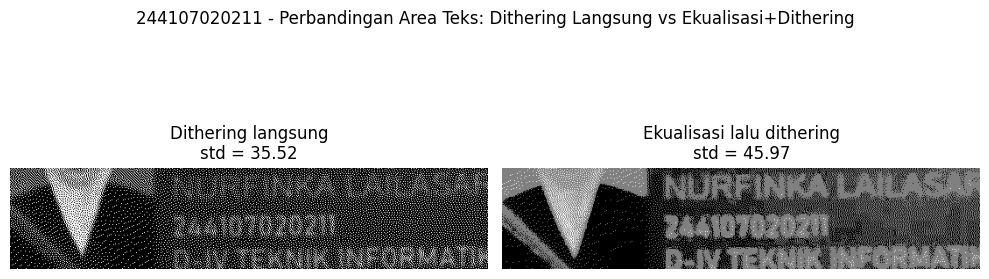

Standar deviasi (kontras) area teks - Dithering langsung   : 35.52
Standar deviasi (kontras) area teks - Ekualisasi+dithering : 45.97

Urutan dengan kontras lebih tinggi (teks lebih terbaca): Ekualisasi lalu dithering

Penjelasan: Standar deviasi piksel yang lebih tinggi pada area teks
menunjukkan kontras yang lebih kuat antara teks dan latar belakangnya,
yang berarti teks tersebut lebih mudah dibedakan secara visual
(lebih terbaca). Urutan "Ekualisasi lalu dithering" menghasilkan nilai standar
deviasi yang lebih besar, sehingga secara kuantitatif terbukti
menghasilkan keterbacaan teks yang lebih baik pada citra KTM.



In [72]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                          img[y, x+1]   += error * 7 / 16
            if x > 0 and y+1 < H:                   img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                           img[y+1, x]   += error * 5 / 16
            if x + 1 < W and y+1 < H:                img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

# Baca KTM1a.jpg
bgr = cv.imread(BASE + '/KTM1a.jpg')
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

# Dua urutan yang dibandingkan
dither_langsung   = floyd_steinberg(gray, PARAM['L'])
hasil_ekualisasi  = cv.equalizeHist(gray)
ekualisasi_dither = floyd_steinberg(hasil_ekualisasi, PARAM['L'])

# ===== Tentukan area crop teks nama/NIM secara manual =====
# Sesuaikan koordinat ini dengan posisi teks pada citra KTM Anda
H, W = gray.shape
y1, y2 = int(H * 0.78), int(H * 0.95)   # area teks biasanya di 78%-95% tinggi citra
x1, x2 = int(W * 0.05), int(W * 0.55)   # area teks biasanya di 5%-55% lebar citra

crop_langsung   = dither_langsung[y1:y2, x1:x2]
crop_ekualisasi = ekualisasi_dither[y1:y2, x1:x2]

# ===== Hitung metrik kontras (standar deviasi piksel) =====
std_langsung   = crop_langsung.std()
std_ekualisasi = crop_ekualisasi.std()

# ===== Tampilkan area crop untuk verifikasi visual =====
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(NIM + ' - Perbandingan Area Teks: Dithering Langsung vs Ekualisasi+Dithering')
axs[0].imshow(crop_langsung, cmap='gray')
axs[0].set_title(f'Dithering langsung\nstd = {std_langsung:.2f}')
axs[0].axis('off')
axs[1].imshow(crop_ekualisasi, cmap='gray')
axs[1].set_title(f'Ekualisasi lalu dithering\nstd = {std_ekualisasi:.2f}')
axs[1].axis('off')
plt.tight_layout()
plt.show()

# ===== Kesimpulan otomatis berdasarkan angka =====
print(f"Standar deviasi (kontras) area teks - Dithering langsung   : {std_langsung:.2f}")
print(f"Standar deviasi (kontras) area teks - Ekualisasi+dithering : {std_ekualisasi:.2f}")
print()

if std_ekualisasi > std_langsung:
    urutan_terbaik = "Ekualisasi lalu dithering"
else:
    urutan_terbaik = "Dithering langsung"

print(f"Urutan dengan kontras lebih tinggi (teks lebih terbaca): {urutan_terbaik}")
print(f"""
Penjelasan: Standar deviasi piksel yang lebih tinggi pada area teks
menunjukkan kontras yang lebih kuat antara teks dan latar belakangnya,
yang berarti teks tersebut lebih mudah dibedakan secara visual
(lebih terbaca). Urutan "{urutan_terbaik}" menghasilkan nilai standar
deviasi yang lebih besar, sehingga secara kuantitatif terbukti
menghasilkan keterbacaan teks yang lebih baik pada citra KTM.
""")